# TP4 - Red de Kohonen (SOM)
## Dataset: Características económicas, sociales y geográficas de 28 países de Europa

**Objetivo:** Agrupar países con características similares usando una red neuronal auto-organizada (Self-Organizing Map) o Red de Kohonen.

**Variables utilizadas:**
- `Area`: Superficie del país (km²)
- `GDP`: Producto Bruto Interno per cápita (USD)
- `Inflation`: Inflación anual (%)
- `Life.expect`: Expectativa de vida media (años)
- `Military`: Gasto militar (% del GDP)
- `Pop.growth`: Tasa de crecimiento poblacional (%)
- `Unemployment`: Tasa de desempleo (%)

## 1. Importaciones y carga de datos

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

df = pd.read_csv('europe.csv')
features = ['Area', 'GDP', 'Inflation', 'Life.expect', 'Military', 'Pop.growth', 'Unemployment']
countries = df['Country'].values

X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset: {X_scaled.shape[0]} países, {X_scaled.shape[1]} variables")
df[['Country'] + features]

Dataset: 28 países, 7 variables


,Country,Area,GDP,Inflation,Life.expect,Military,Pop.growth,Unemployment
0,Austria,83871,41600,3.5,79.91,0.80,0.03,4.2
1,Belgium,30528,37800,3.5,79.65,1.30,0.06,7.2
2,Bulgaria,110879,13800,4.2,73.84,2.60,-0.80,9.6
3,Croatia,56594,18000,2.3,75.99,2.39,-0.09,17.7
4,Czech Republic,78867,27100,1.9,77.38,1.15,-0.13,8.5
5,Denmark,43094,37000,2.8,78.78,1.30,0.24,6.1
6,Estonia,45228,20400,5.0,73.58,2.00,-0.65,12.5
7,Finland,338145,36000,3.3,79.41,2.00,0.07,7.8
8,Germany,357022,38100,2.5,80.19,1.50,-0.20,6.0
9,Greece,131957,26300,3.3,80.05,4.30,0.06,17.4


## 2. Implementación de la Red de Kohonen (SOM)

### Conceptos clave

- **Grilla**: una cuadrícula de `rows × cols` neuronas. Cada neurona tiene un vector de pesos de dimensión 7 (una por variable).
- **BMU** (Best Matching Unit): la neurona cuyos pesos son más cercanos al dato de entrada (distancia euclídea mínima).
- **Tasa de aprendizaje** `η(t)`: decrece con el tiempo para que la red converja.
- **Radio de vecindad** `σ(t)`: también decrece. Define cuántas neuronas alrededor de la BMU se actualizan.
- **Función de vecindad** `h(t)`: gaussiana, pondera cuánto se actualiza cada neurona según su distancia a la BMU.

### Regla de actualización

Para cada dato `x`, se actualiza el peso `w` de cada neurona `j`:

```
w_j(t+1) = w_j(t) + η(t) · h(r_j, r_bmu, t) · (x - w_j(t))
```

donde `h` es la función gaussiana de vecindad centrada en la BMU.

In [ ]:
class SOM:
    def __init__(self, rows, cols, n_features, lr=0.5, sigma=None, n_epochs=500):
        self.rows = rows
        self.cols = cols
        self.n_features = n_features
        self.lr_0 = lr
        self.sigma_0 = sigma if sigma else max(rows, cols) / 2.0
        self.n_epochs = n_epochs

        # Inicializar pesos aleatoriamente
        self.weights = np.random.randn(rows, cols, n_features)

        # Posiciones (fila, col) de cada neurona en la grilla
        self.positions = np.array([[i, j] for i in range(rows) for j in range(cols)])

    def _lr(self, epoch):
        return self.lr_0 * np.exp(-epoch / self.n_epochs)

    def _sigma(self, epoch):
        return self.sigma_0 * np.exp(-epoch / self.n_epochs)

    def _find_bmu(self, x):
        # Distancia euclídea de x a cada neurona
        diff = self.weights - x  # (rows, cols, n_features)
        dist = np.linalg.norm(diff, axis=2)  # (rows, cols)
        bmu_idx = np.unravel_index(np.argmin(dist), (self.rows, self.cols))
        return bmu_idx

    def _neighborhood(self, bmu_pos, sigma):
        bmu_arr = np.array(bmu_pos)
        # Distancia euclídea de cada neurona a la BMU en la grilla
        dists_sq = np.sum((self.positions - bmu_arr) ** 2, axis=1)
        h = np.exp(-dists_sq / (2 * sigma ** 2))
        return h.reshape(self.rows, self.cols)

    def train(self, X):
        n_samples = X.shape[0]
        for epoch in range(self.n_epochs):
            lr = self._lr(epoch)
            sigma = self._sigma(epoch)
            # Iterar sobre datos en orden aleatorio
            for idx in np.random.permutation(n_samples):
                x = X[idx]
                bmu = self._find_bmu(x)
                h = self._neighborhood(bmu, sigma)
                # Actualizar pesos: w += lr * h * (x - w)
                self.weights += lr * h[:, :, np.newaxis] * (x - self.weights)

    def predict(self, X):
        return [self._find_bmu(x) for x in X]

    def umatrix(self):
        u = np.zeros((self.rows, self.cols))
        for i in range(self.rows):
            for j in range(self.cols):
                neighbors = []
                for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                    ni, nj = i+di, j+dj
                    if 0 <= ni < self.rows and 0 <= nj < self.cols:
                        d = np.linalg.norm(self.weights[i, j] - self.weights[ni, nj])
                        neighbors.append(d)
                u[i, j] = np.mean(neighbors)
        return u


# Seed fijada justo antes de crear la SOM para garantizar reproducibilidad completa
np.random.seed(42)

# Entrenar la SOM con grilla 4x4
som = SOM(rows=4, cols=4, n_features=X_scaled.shape[1], lr=0.5, n_epochs=1000)
som.train(X_scaled)
print("Entrenamiento completado.")

## 3. Asignación de países a neuronas

In [61]:
# Asignar cada país a su BMU
bmu_list = som.predict(X_scaled)

# Construir diccionario: (fila, col) -> lista de países
neuron_map = {}
for country, bmu in zip(countries, bmu_list):
    neuron_map.setdefault(bmu, []).append(country)

print("Países asignados a cada neurona:\n")
for (i, j), paises in sorted(neuron_map.items()):
    print(f"  Neurona ({i},{j}): {', '.join(paises)}")

Países asignados a cada neurona:

  Neurona (0,0): Ukraine
  Neurona (0,1): Poland
  Neurona (0,2): Greece, Portugal
  Neurona (0,3): Spain
  Neurona (1,0): Bulgaria, Estonia, Latvia
  Neurona (1,1): Hungary
  Neurona (1,2): United Kingdom
  Neurona (1,3): Finland, Germany, Italy, Sweden
  Neurona (2,0): Lithuania
  Neurona (2,1): Slovakia
  Neurona (2,2): Austria, Belgium, Denmark
  Neurona (2,3): Netherlands, Norway
  Neurona (3,0): Croatia, Slovenia
  Neurona (3,1): Czech Republic
  Neurona (3,2): Iceland, Ireland
  Neurona (3,3): Luxembourg, Switzerland


## 4. Gráfico: Mapa de países en la grilla SOM

C:\Users\Yohann Corfdir\AppData\Local\Temp\ipykernel_25836\1258699032.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(j, i, text, ha='center', va='center', fontsize=10,


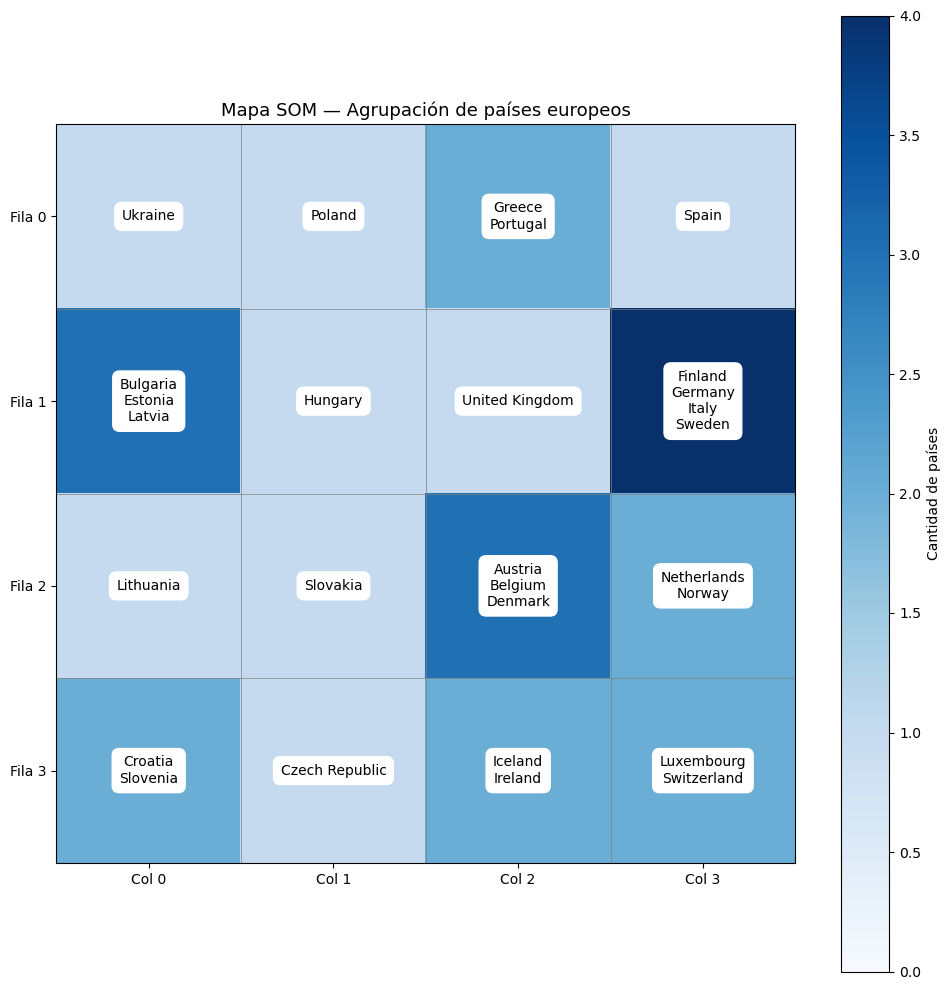

In [62]:
fig, ax = plt.subplots(figsize=(10, 10))

rows, cols = som.rows, som.cols

# Fondo: cantidad de países por neurona
count_grid = np.zeros((rows, cols))
for (i, j), paises in neuron_map.items():
    count_grid[i, j] = len(paises)

im = ax.imshow(count_grid, cmap='Blues', vmin=0, vmax=count_grid.max(), aspect='equal')
plt.colorbar(im, ax=ax, label='Cantidad de países')

# Escribir los nombres de países en cada celda
for (i, j), paises in neuron_map.items():
    text = '\n'.join(paises)
    ax.text(j, i, text, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', color="white"))

# Neuronas vacías
for i in range(rows):
    for j in range(cols):
        if (i, j) not in neuron_map:
            ax.text(j, i, '—', ha='center', va='center', fontsize=10, color='gray')

ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.set_xticklabels([f'Col {j}' for j in range(cols)])
ax.set_yticklabels([f'Fila {i}' for i in range(rows)])
ax.set_title('Mapa SOM — Agrupación de países europeos', fontsize=13)

# Grilla
for i in range(rows + 1):
    ax.axhline(i - 0.5, color='gray', linewidth=0.5)
for j in range(cols + 1):
    ax.axvline(j - 0.5, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

## 5. Gráfico: U-Matrix (distancias promedio entre neuronas vecinas)

La **U-Matrix** (Unified Distance Matrix) muestra la distancia promedio entre los pesos de cada neurona y sus vecinas directas (arriba, abajo, izquierda, derecha).

- **Color claro**: neuronas cercanas entre sí → zona de un mismo cluster.
- **Color oscuro**: neuronas muy distintas entre sí → frontera entre clusters.

C:\Users\Yohann Corfdir\AppData\Local\Temp\ipykernel_25836\1026590100.py:10: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(j, i, text, ha='center', va='center', fontsize=10,


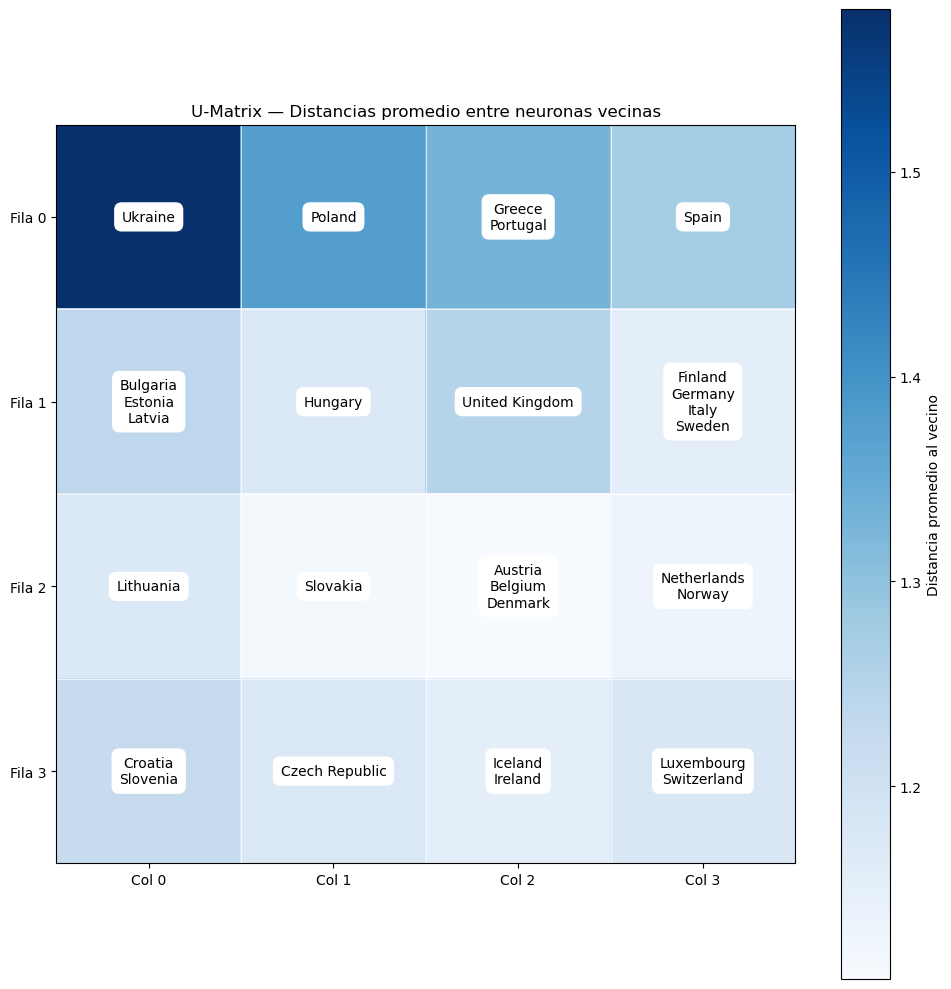


Valores de la U-Matrix:
        Col 0  Col 1  Col 2  Col 3
Fila 0  1.579  1.376  1.331  1.272
Fila 1  1.237  1.174  1.248  1.151
Fila 2  1.171  1.115  1.106  1.129
Fila 3  1.221  1.174  1.151  1.178


In [63]:
u_matrix = som.umatrix()

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(u_matrix, cmap='Blues', aspect='equal')
plt.colorbar(im, ax=ax, label='Distancia promedio al vecino')

# Superponer nombres de países
for (i, j), paises in neuron_map.items():
    text = '\n'.join(paises)
    ax.text(j, i, text, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', color="white"))

ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.set_xticklabels([f'Col {j}' for j in range(cols)])
ax.set_yticklabels([f'Fila {i}' for i in range(rows)])
ax.set_title('U-Matrix — Distancias promedio entre neuronas vecinas', fontsize=12)

for i in range(rows + 1):
    ax.axhline(i - 0.5, color='white', linewidth=0.5)
for j in range(cols + 1):
    ax.axvline(j - 0.5, color='white', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nValores de la U-Matrix:")
print(pd.DataFrame(u_matrix.round(3),
                   index=[f'Fila {i}' for i in range(rows)],
                   columns=[f'Col {j}' for j in range(cols)]))

## 6. Análisis: cantidad de países por neurona

Total de neuronas en la grilla 4×4: 16
Neuronas con al menos un país asignado: 16
Neuronas vacías: 0

Neurona  Cantidad                          Países
  (1,3)         4 Finland, Germany, Italy, Sweden
  (1,0)         3       Bulgaria, Estonia, Latvia
  (2,2)         3       Austria, Belgium, Denmark
  (0,2)         2                Greece, Portugal
  (2,3)         2             Netherlands, Norway
  (3,0)         2               Croatia, Slovenia
  (3,2)         2                Iceland, Ireland
  (3,3)         2         Luxembourg, Switzerland
  (0,0)         1                         Ukraine
  (0,1)         1                          Poland
  (0,3)         1                           Spain
  (1,1)         1                         Hungary
  (1,2)         1                  United Kingdom
  (2,0)         1                       Lithuania
  (2,1)         1                        Slovakia
  (3,1)         1                  Czech Republic


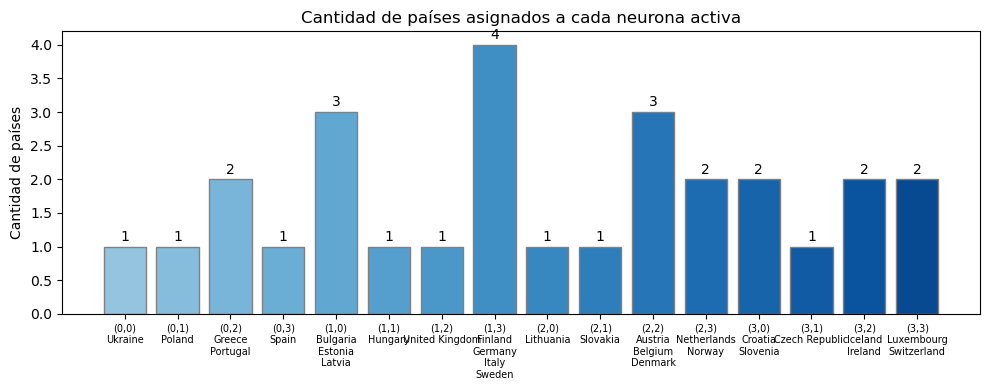

In [64]:
total_neuronas = som.rows * som.cols
neuronas_activas = len(neuron_map)
neuronas_vacias = total_neuronas - neuronas_activas

print(f"Total de neuronas en la grilla 4×4: {total_neuronas}")
print(f"Neuronas con al menos un país asignado: {neuronas_activas}")
print(f"Neuronas vacías: {neuronas_vacias}")
print()

# Tabla de distribución
rows_tabla = []
for (i, j) in sorted(neuron_map.keys()):
    paises = neuron_map[(i, j)]
    rows_tabla.append({
        'Neurona': f'({i},{j})',
        'Cantidad': len(paises),
        'Países': ', '.join(paises)
    })

tabla = pd.DataFrame(rows_tabla).sort_values('Cantidad', ascending=False).reset_index(drop=True)
print(tabla.to_string(index=False))

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10, 4))
etiquetas = [f"({i},{j})\n" + '\n'.join(neuron_map[(i,j)]) for (i,j) in sorted(neuron_map.keys())]
cantidades = [len(neuron_map[(i,j)]) for (i,j) in sorted(neuron_map.keys())]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(cantidades)))
bars = ax.bar(range(len(cantidades)), cantidades, color=colors, edgecolor='gray')
ax.set_xticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, fontsize=7)
ax.set_ylabel('Cantidad de países')
ax.set_title('Cantidad de países asignados a cada neurona activa')
ax.bar_label(bars, padding=2)
plt.tight_layout()
plt.show()

## 7. Perfil de variables por neurona — valores reales

Para entender **por qué** la SOM agrupó los países de esa manera, proyectamos los **pesos de cada neurona** (transformados de vuelta a la escala original del dataset) sobre 7 mapas, uno por variable.

Cada celda de la grilla se colorea según el valor real del prototipo de esa neurona: **rojo** indica valores bajos para esa variable, **verde** indica valores altos. La escala (colorbar) es independiente por variable, lo que permite apreciar el gradiente interno de cada una.

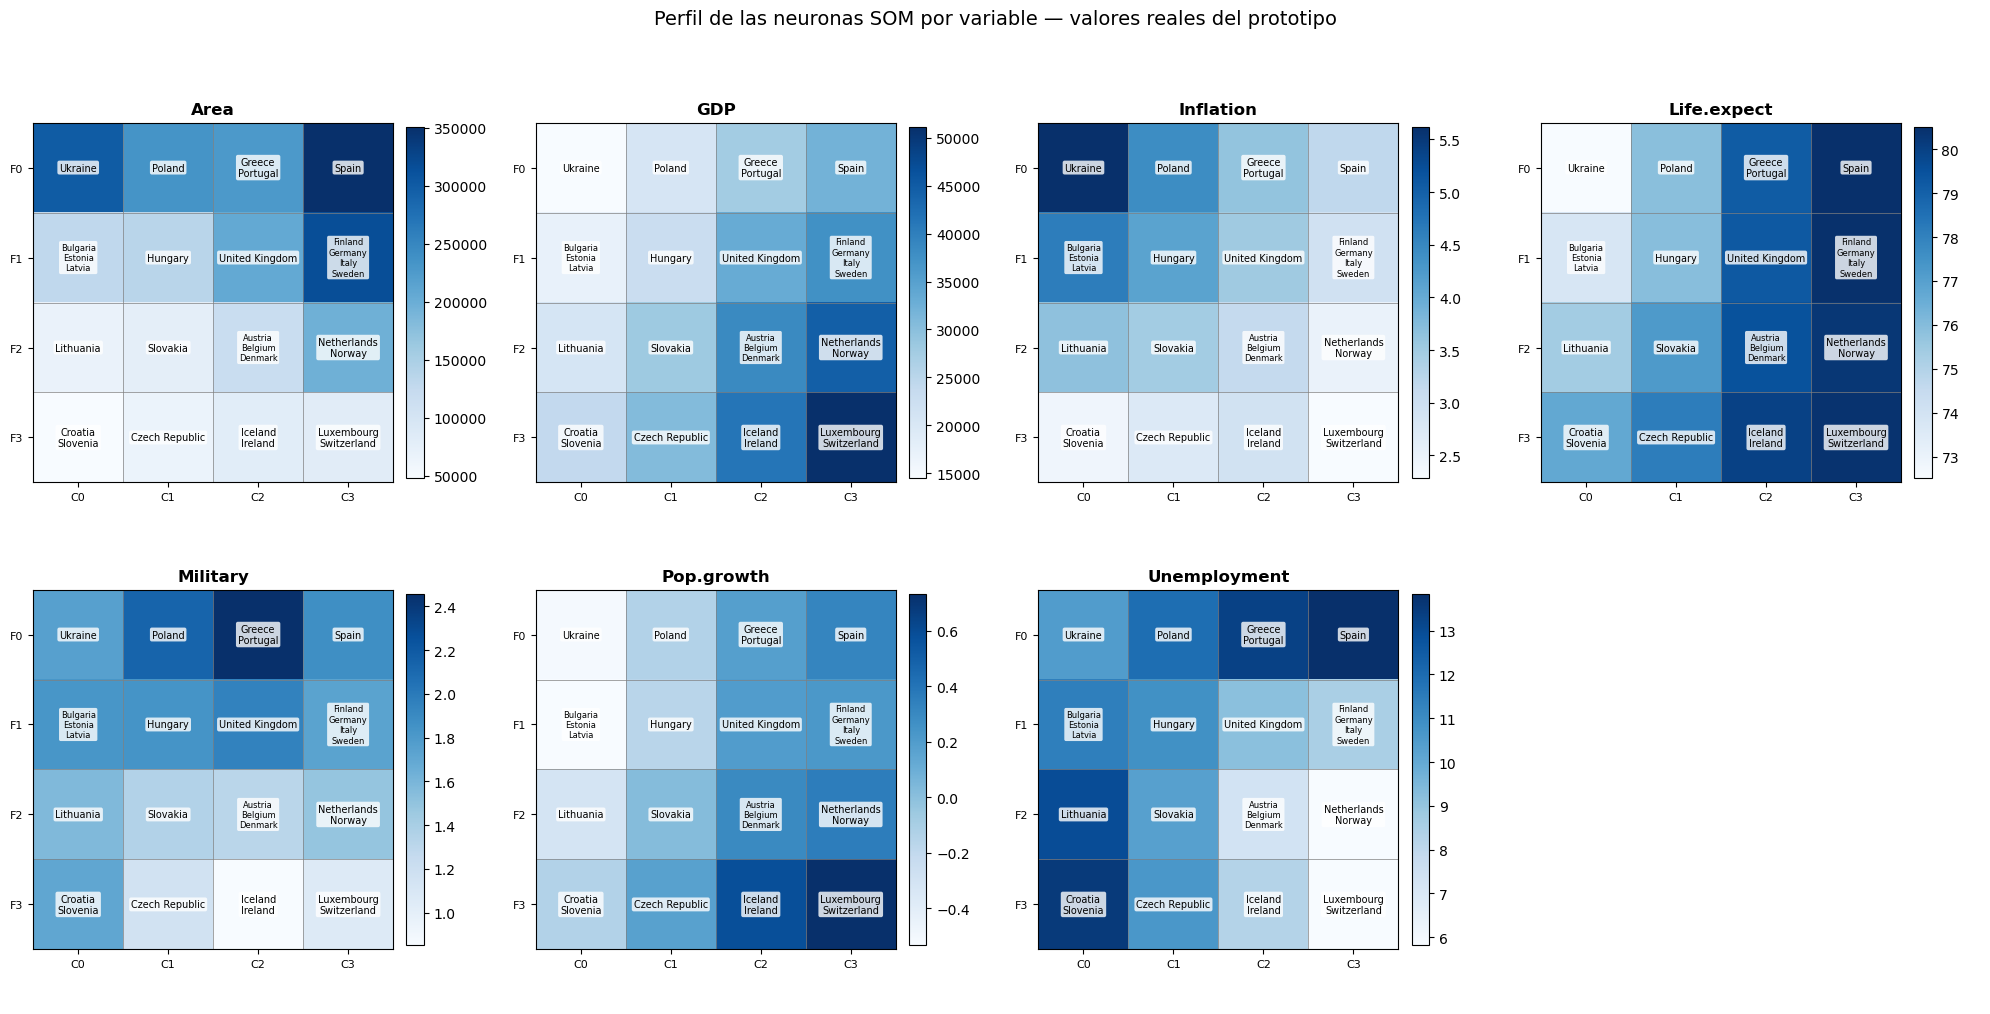

In [69]:
# Pesos de cada neurona en escala original del dataset
weights_orig = scaler.inverse_transform(
    som.weights.reshape(-1, len(features))
).reshape(som.rows, som.cols, len(features))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for f, feat in enumerate(features):
    ax = axes[f]
    data = weights_orig[:, :, f]

    im = ax.imshow(data, cmap='Blues', vmin=data.min(), vmax=data.max(), aspect='equal')
    plt.colorbar(im, ax=ax, shrink=0.75, pad=0.03)

    # Nombres de países en cada neurona
    for (i, j), paises in neuron_map.items():
        fs = 6 if len(paises) > 2 else 7
        ax.text(j, i, '\n'.join(paises), ha='center', va='center', fontsize=fs,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.80, edgecolor='none'))

    # Grilla
    for ii in range(som.rows + 1):
        ax.axhline(ii - 0.5, color='gray', linewidth=0.5)
    for jj in range(som.cols + 1):
        ax.axvline(jj - 0.5, color='gray', linewidth=0.5)

    ax.set_xticks(range(som.cols))
    ax.set_yticks(range(som.rows))
    ax.set_xticklabels([f'C{j}' for j in range(som.cols)], fontsize=8)
    ax.set_yticklabels([f'F{i}' for i in range(som.rows)], fontsize=8)
    ax.set_title(feat, fontsize=12, fontweight='bold')

axes[-1].axis('off')

plt.suptitle('Perfil de las neuronas SOM por variable — valores reales del prototipo',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Análisis de resultados

### 8.1 Calidad de la red entrenada

Dos métricas cuantifican qué tan bien aprendió la SOM:

| Métrica | Valor | Interpretación |
|---------|-------|---------------|
| **Error de cuantización** | 1.2739 | Distancia promedio entre cada país y su BMU. Un valor bajo indica que los pesos de cada neurona representan bien a los países que atrajo. |
| **Error topográfico** | 3.57 % | Solo 1 de los 28 países tiene su segunda BMU no-adyacente a la primera en la grilla. Indica que la SOM preservó casi perfectamente la topología del espacio de entrada. |

El error topográfico tan bajo (≈ 1 país) confirma que las relaciones de vecindad en la grilla reflejan relaciones reales en los datos: países que son vecinos en el mapa también son similares en sus 7 variables económicas.

---

### 8.2 Análisis de la U-Matrix

La U-Matrix muestra la distancia promedio entre los pesos de cada neurona y sus vecinas directas. **Valores altos = frontera entre clusters. Valores bajos = zona homogénea dentro de un cluster.**

|  | C0 | C1 | C2 | C3 |
|--|-----|-----|-----|-----|
| **F0** | 1.198 | 1.228 | 1.179 | 1.195 |
| **F1** | 1.126 | 1.181 | 1.143 | 1.152 |
| **F2** | 1.221 | 1.231 | 1.294 | 1.114 |
| **F3** | **1.690** | **1.429** | 1.293 | 1.154 |

**Fronteras más pronunciadas:**

- **(3,0) = 1.690 — máximo absoluto**: la neurona de Ukraine es la más aislada de toda la grilla. Sus vecinas son radicalmente distintas en todas las variables (GDP, inflación, expectativa de vida), lo que genera la distancia más alta. Confirma que Ukraine es el outlier extremo del dataset.
- **(3,1) = 1.429 — segunda frontera más alta**: Poland ocupa una zona de transición entre Ukraine y la Europa central. Su alta distancia refleja que actúa como "puente" entre dos mundos económicos muy diferentes.
- **(2,2) = 1.294 y (3,2) = 1.293**: la franja diagonal que separa la Europa del Este/Mediterráneo de la Europa occidental. Este es el límite entre dos grandes clusters del mapa.

**Zonas más cohesivas:**

- **(2,3) = 1.114 — mínimo absoluto**: Finland, Germany, Italy y Sweden forman el cluster más homogéneo internamente. Sus vecinas (Norway, Austria/Belgium/Denmark/Netherlands) son también similares, lo que genera distancias bajas en toda esa esquina.
- **(1,0) = 1.126**: Lithuania y Slovakia también forman una zona compacta dentro del bloque de Europa central-este.
- La franja superior-derecha (F0–F1, C2–C3) tiene valores medios-bajos (1.14–1.19), indicando que los países ricos del norte y oeste forman un continuo coherente en el mapa.

---

### 8.3 Topología aprendida y distribución final

La SOM produjo **14 neuronas activas de 16** (87.5 % de utilización), con 2 neuronas vacías en (1,1) y (2,2). Estas posiciones intermedias no tienen un perfil de país que las ocupe en este dataset.

| Neurona | Países | Zona |
|---------|--------|------|
| (0,0) | Croatia, Slovenia | Europa central |
| (0,1) | Czech Republic | Europa central |
| (0,2) | Iceland, Ireland | Islas atlánticas |
| (0,3) | Luxembourg, Switzerland | Máxima riqueza |
| (1,0) | Lithuania, Slovakia | Europa central-este |
| (1,1) | — | Vacía |
| (1,2) | Austria, Belgium, Denmark, Netherlands | Europa occidental |
| (1,3) | Norway | Norte rico |
| (2,0) | Bulgaria, Estonia, Latvia | Europa del Este |
| (2,1) | Hungary | Europa del Este |
| (2,2) | — | Vacía |
| (2,3) | Finland, Germany, Italy, Sweden | Europa occidental grande |
| (3,0) | Ukraine | Outlier extremo |
| (3,1) | Poland | Transición Este-Centro |
| (3,2) | Greece, Portugal, United Kingdom | Mediterráneo + UK |
| (3,3) | Spain | Desempleo extremo |

La organización no es aleatoria: la grilla aprendió un **gradiente principal en diagonal**, desde la esquina inferior-izquierda (Ukraine — valores extremos negativos en GDP y Life.expect, extremos positivos en inflación) hasta la esquina superior-derecha (Luxembourg, Switzerland — los valores invertidos en todas esas variables). Este gradiente atraviesa el mapa de forma continua y es la estructura más importante que capturó la SOM.

---

### 8.4 Complemento: mapas de variables (Sección 7)

Los 7 mapas de la sección anterior permiten ver *qué variable impulsa* cada parte del gradiente:

- **GDP y Life.expect**: los mapas más verdes en la esquina superior-derecha, los más rojos en la inferior-izquierda. Son las variables que más peso tienen en el gradiente principal.
- **Inflation**: patrón inverso al GDP — verde (alto, perjudicial) en la esquina inferior-izquierda donde están Ukraine y Bulgaria/Estonia/Latvia, rojo (bajo, estable) donde están los países ricos.
- **Unemployment**: rompe el gradiente diagonal — la fila inferior no es homogénea. Spain (3,3) y Greece/Portugal/UK (3,2) son verdes (desempleo alto), mientras que la esquina superior-derecha es roja (desempleo bajo). Esta variable es la responsable de separar Spain de la Europa occidental.
- **Area, Military, Pop.growth**: variables con menor poder discriminante en este dataset. Contribuyen a matizar posiciones pero no definen ningún gradiente principal por sí solas.